In [1]:
!nvidia-smi -L
!pip -q install ultralytics pyyaml opencv-python pandas

from ultralytics import YOLO
import os, glob, yaml, shutil
from pathlib import Path
import pandas as pd

GPU 0: Tesla T4 (UUID: GPU-9f398c1e-872b-42fd-d411-f0a7d3a33674)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from google.colab import files

uploaded = files.upload()   # upload your .zip here
zip_name = next(iter(uploaded.keys()))
print("Uploaded:", zip_name)

# unzip
DATA_DIR = Path("/content/dataset")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!unzip -q "{zip_name}" -d /content/dataset

print("Unzipped into:", DATA_DIR)
!ls -lah /content/dataset | head -n 50

Saving BlueBerries.v1-deepfruits-blueberries.yolov11.zip to BlueBerries.v1-deepfruits-blueberries.yolov11.zip
Uploaded: BlueBerries.v1-deepfruits-blueberries.yolov11.zip
Unzipped into: /content/dataset
total 32K
drwxr-xr-x 5 root root 4.0K Feb 23 20:35 .
drwxr-xr-x 1 root root 4.0K Feb 23 20:35 ..
-rw-r--r-- 1 root root  266 May  2  2025 data.yaml
-rw-r--r-- 1 root root 1.2K May  2  2025 README.dataset.txt
-rw-r--r-- 1 root root  896 May  2  2025 README.roboflow.txt
drwxr-xr-x 4 root root 4.0K May  2  2025 test
drwxr-xr-x 4 root root 4.0K May  2  2025 train
drwxr-xr-x 4 root root 4.0K May  2  2025 valid


In [3]:
# Find data.yaml anywhere inside extracted folder
yaml_candidates = glob.glob("/content/dataset/**/data.yaml", recursive=True)
if not yaml_candidates:
    raise FileNotFoundError("data.yaml not found. Make sure you exported YOLO format from Roboflow.")
data_yaml_path = Path(yaml_candidates[0])
print("Found data.yaml:", data_yaml_path)

# dataset root = folder containing data.yaml
dataset_root = data_yaml_path.parent
print("Dataset root:", dataset_root)

# Load YAML
with open(data_yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

print("Original YAML keys:", list(data_cfg.keys()))
print(data_cfg)

# Helper: convert path to absolute if needed
def resolve_split_path(p):
    p = str(p)
    # If YOLO yaml uses relative paths, resolve against dataset_root
    # Examples: "train/images", "../train/images"
    abs_path = (dataset_root / p).resolve()
    return str(abs_path)

# Build a fixed YAML for ultralytics
fixed = dict(data_cfg)

# Ultralytics can use absolute paths directly
if "train" in fixed:
    fixed["train"] = resolve_split_path(fixed["train"])
if "val" in fixed:
    fixed["val"] = resolve_split_path(fixed["val"])
if "test" in fixed:
    fixed["test"] = resolve_split_path(fixed["test"])

# Ensure class names exist
# Some yaml uses: names: {0:'blueberries'} or names: ['blueberries']
# Keep as-is if present
if "names" not in fixed and "nc" in fixed:
    fixed["names"] = [f"class_{i}" for i in range(int(fixed["nc"]))]

fixed_yaml_path = Path("/content/fixed_data.yaml")
with open(fixed_yaml_path, "w") as f:
    yaml.safe_dump(fixed, f, sort_keys=False)

print("\n✅ Saved fixed YAML:", fixed_yaml_path)
print("Fixed YAML content:\n", fixed)

Found data.yaml: /content/dataset/data.yaml
Dataset root: /content/dataset
Original YAML keys: ['train', 'val', 'test', 'nc', 'names', 'roboflow']
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['1'], 'roboflow': {'workspace': 'inkyu-sa-e0c78', 'project': 'blueberries-u0e84', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/inkyu-sa-e0c78/blueberries-u0e84/dataset/1'}}

✅ Saved fixed YAML: /content/fixed_data.yaml
Fixed YAML content:
 {'train': '/content/train/images', 'val': '/content/valid/images', 'test': '/content/test/images', 'nc': 1, 'names': ['1'], 'roboflow': {'workspace': 'inkyu-sa-e0c78', 'project': 'blueberries-u0e84', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/inkyu-sa-e0c78/blueberries-u0e84/dataset/1'}}


In [5]:
import os, glob, yaml
from pathlib import Path

def count_images(folder):
    exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
    total = 0
    for e in exts:
        total += len(glob.glob(str(Path(folder)/"**"/e), recursive=True))
    return total

# 1) find ALL possible train/images folders inside your extracted dataset
train_candidates = glob.glob("/content/dataset/**/train/images", recursive=True)
if not train_candidates:
    raise FileNotFoundError("Couldn't find any train/images folder inside /content/dataset. Check unzip output.")

# 2) pick the one with most images (usually the correct dataset root)
best_train_images = max(train_candidates, key=count_images)
root = Path(best_train_images).parents[1]   # .../<root>/train/images -> parents[1] = <root>
print("✅ Using dataset root:", root)
print("Train images folder:", best_train_images, "images:", count_images(best_train_images))

# 3) detect val folder name: valid/images or val/images
val_path = None
for cand in [root/"valid/images", root/"val/images"]:
    if cand.exists():
        val_path = cand
        break
if val_path is None:
    raise FileNotFoundError("Couldn't find valid/images or val/images next to train/. Check your folder structure.")

print("Val images folder:", val_path, "images:", count_images(val_path))

# 4) read original data.yaml (if present) to keep class names
yaml_candidates = glob.glob(str(root/"data.yaml"))
names = None
nc = None
if yaml_candidates:
    with open(yaml_candidates[0], "r") as f:
        orig = yaml.safe_load(f)
    names = orig.get("names", None)
    nc = orig.get("nc", None)

# 5) create a clean Ultralytics YAML (relative paths + correct root)
fixed = {
    "path": str(root),
    "train": "train/images",
    "val": ("valid/images" if (root/"valid/images").exists() else "val/images"),
}

# keep names if found
if names is not None:
    fixed["names"] = names
if nc is not None:
    fixed["nc"] = nc

fixed_yaml_path = Path("/content/fixed_data.yaml")
with open(fixed_yaml_path, "w") as f:
    yaml.safe_dump(fixed, f, sort_keys=False)

print("\n✅ Wrote fixed yaml:", fixed_yaml_path)
print(fixed)

✅ Using dataset root: /content/dataset
Train images folder: /content/dataset/train/images images: 63
Val images folder: /content/dataset/valid/images images: 8

✅ Wrote fixed yaml: /content/fixed_data.yaml
{'path': '/content/dataset', 'train': 'train/images', 'val': 'valid/images', 'names': ['1'], 'nc': 1}


In [ ]:
# Final Test + Guaranteed Annotation
from google.colab import files

model = YOLO("/content/runs/detect/blueberry_yolo11n/weights/best.pt")

uploaded = files.upload()   # Upload 1-3 test images or cancel for demo

if len(uploaded) == 0:
    !wget -q https://i.imgur.com/3vKzL8p.jpg -O test_bush.jpg
    uploaded = {"test_bush.jpg": None}

for filename in uploaded.keys():
    img = cv2.imread(filename)
    results = model(img, conf=0.3, verbose=False)

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 5)
            cv2.putText(img, f"Berry: {box.conf[0]:.2f}", (x1, y1-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 3)

    cv2.imwrite("FINAL_ANNOTATED.jpg", img)
    print("✅ Annotated image saved with green boxes!")
    files.download("FINAL_ANNOTATED.jpg")

Saving Aurora_Blueberry_1_650x_jpg.rf.1620e2d254ccf98cc8eddfce8fc05ba1.jpg to Aurora_Blueberry_1_650x_jpg.rf.1620e2d254ccf98cc8eddfce8fc05ba1 (2).jpg
✅ Annotated image saved with green boxes!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import os, yaml
from pathlib import Path

with open("/content/fixed_data.yaml", "r") as f:
    cfg = yaml.safe_load(f)

train_dir = str(Path(cfg["path"]) / cfg["train"])
val_dir   = str(Path(cfg["path"]) / cfg["val"])

print("Train path:", train_dir, "exists:", os.path.exists(train_dir))
print("Val path:", val_dir, "exists:", os.path.exists(val_dir))

Train path: /content/dataset/train/images exists: True
Val path: /content/dataset/valid/images exists: True


In [7]:
from ultralytics import YOLO

# Load a small pretrained model (fast + good for demo)
model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/fixed_data.yaml",
    epochs=120,           # small dataset → train longer + early stopping
    imgsz=640,            # increase to 768/1024 later for tiny berries
    batch=16,             # if GPU memory error → set 8
    patience=25,          # early stopping
    optimizer="AdamW",
    lr0=0.002,
    weight_decay=0.0005,
    warmup_epochs=3,
    close_mosaic=10,      # turns off mosaic near end for stability
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5, translate=0.05, scale=0.4,
    fliplr=0.5,
    mosaic=1.0,
    workers=2
)

print("✅ Training done. Best weights saved at: runs/detect/train/weights/best.pt")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fixed_data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=25, perspective=0.0,

In [12]:
from ultralytics import YOLO

BEST_WEIGHTS = "runs/detect/train/weights/best.pt"
model = YOLO(BEST_WEIGHTS)
print("Loaded:", BEST_WEIGHTS)

Loaded: runs/detect/train/weights/best.pt


In [13]:
metrics = model.val(
    data="/content/fixed_data.yaml",
    imgsz=640,
    conf=0.25
)
print(metrics)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1317.3±704.9 MB/s, size: 93.9 KB)
val: Scanning /content/dataset/valid/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 2.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.7it/s 0.3s
                   all          8        571      0.905      0.853      0.918      0.597
Speed: 1.6ms preprocess, 5.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea4a41ff200>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confi

In [14]:
import yaml
from pathlib import Path

with open("/content/fixed_data.yaml", "r") as f:
    cfg = yaml.safe_load(f)

root = Path(cfg["path"])
val_images_dir = root / cfg["val"]

preds = model.predict(
    source=str(val_images_dir),
    imgsz=640,
    conf=0.25,
    save=True
)

print("✅ Saved prediction images in:", preds[0].save_dir)


image 1/8 /content/dataset/valid/images/65897A--1-_jpg.rf.8db1687650801c5fd3fe843f75011010.jpg: 640x640 47 1s, 7.2ms
image 2/8 /content/dataset/valid/images/BU133-2_jpg.rf.b55d46e3b91a4e163ea97056a7debc65.jpg: 576x640 14 1s, 7.8ms
image 3/8 /content/dataset/valid/images/Dreamstime_blueberry_bush_large_jpg.rf.a209992901d239ce8d1486b0a1e50958.jpg: 448x640 34 1s, 6.6ms
image 4/8 /content/dataset/valid/images/Sunshineblue09sq_jpeg.rf.735bf1ee5924498dedd8b842eb0f98f5.jpg: 640x640 35 1s, 8.0ms
image 5/8 /content/dataset/valid/images/blueberry-vaccinium-nelson-9cm-p3876-30388_image_png.rf.fc1a71173370b72a107aa4bfb4c7e809.jpg: 640x640 177 1s, 7.2ms
image 6/8 /content/dataset/valid/images/double-a-vineyards_jersey_jpg.rf.d752b17e458877366dcc5420cac421f1.jpg: 640x640 181 1s, 7.3ms
image 7/8 /content/dataset/valid/images/istockphoto-171314137-612x612--1-_jpg.rf.edebd2548dcc9847f94773c4a0486036.jpg: 640x448 53 1s, 6.5ms
image 8/8 /content/dataset/valid/images/pg-blueberry-800x800--1-_jpg.rf.13ce1

In [15]:
import glob
import pandas as pd
from pathlib import Path

image_paths = []
for ext in ["*.jpg","*.jpeg","*.png","*.webp","*.bmp"]:
    image_paths += glob.glob(str(val_images_dir/"**"/ext), recursive=True)

rows = []
for img in sorted(image_paths):
    r = model.predict(img, imgsz=640, conf=0.25, verbose=False)[0]
    pred_count = 0 if r.boxes is None else len(r.boxes)
    rows.append({"image": Path(img).name, "pred_count": int(pred_count)})

df_pred = pd.DataFrame(rows)
df_pred.to_csv("/content/berry_pred_counts.csv", index=False)
print("✅ Saved: /content/berry_pred_counts.csv")
df_pred.head(10)

✅ Saved: /content/berry_pred_counts.csv


,image,pred_count
0,65897A--1-_jpg.rf.8db1687650801c5fd3fe843f7501...,47
1,BU133-2_jpg.rf.b55d46e3b91a4e163ea97056a7debc6...,14
2,Dreamstime_blueberry_bush_large_jpg.rf.a209992...,34
3,Sunshineblue09sq_jpeg.rf.735bf1ee5924498dedd8b...,35
4,blueberry-vaccinium-nelson-9cm-p3876-30388_ima...,177
5,double-a-vineyards_jersey_jpg.rf.d752b17e45887...,181
6,istockphoto-171314137-612x612--1-_jpg.rf.edebd...,53
7,pg-blueberry-800x800--1-_jpg.rf.13ce16dc6c5c48...,60


In [16]:
import numpy as np

# Roboflow structure usually mirrors images -> labels
val_labels_dir = Path(str(val_images_dir).replace("images", "labels"))

def gt_count(img_path: Path) -> int:
    lbl = val_labels_dir / (img_path.stem + ".txt")
    if not lbl.exists():
        return 0
    lines = [ln for ln in lbl.read_text().splitlines() if ln.strip()]
    return len(lines)

rows = []
for img in sorted(image_paths):
    imgp = Path(img)
    gt = gt_count(imgp)

    r = model.predict(str(imgp), imgsz=640, conf=0.25, verbose=False)[0]
    pred = 0 if r.boxes is None else len(r.boxes)

    rows.append({
        "image": imgp.name,
        "gt_count": int(gt),
        "pred_count": int(pred),
        "error": int(pred - gt),
        "abs_error": int(abs(pred - gt)),
    })

df_eval = pd.DataFrame(rows)
mae = df_eval["abs_error"].mean()
rmse = np.sqrt((df_eval["error"]**2).mean())

df_eval.to_csv("/content/berry_count_eval.csv", index=False)
print("✅ Saved: /content/berry_count_eval.csv")
print("MAE:", mae, "| RMSE:", rmse)
df_eval.head(10)

✅ Saved: /content/berry_count_eval.csv
MAE: 9.0 | RMSE: 10.747092630102339


,image,gt_count,pred_count,error,abs_error
0,65897A--1-_jpg.rf.8db1687650801c5fd3fe843f7501...,35,47,12,12
1,BU133-2_jpg.rf.b55d46e3b91a4e163ea97056a7debc6...,8,14,6,6
2,Dreamstime_blueberry_bush_large_jpg.rf.a209992...,29,34,5,5
3,Sunshineblue09sq_jpeg.rf.735bf1ee5924498dedd8b...,39,35,-4,4
4,blueberry-vaccinium-nelson-9cm-p3876-30388_ima...,194,177,-17,17
5,double-a-vineyards_jersey_jpg.rf.d752b17e45887...,162,181,19,19
6,istockphoto-171314137-612x612--1-_jpg.rf.edebd...,46,53,7,7
7,pg-blueberry-800x800--1-_jpg.rf.13ce16dc6c5c48...,58,60,2,2


In [17]:
model.export(format="onnx")
print("✅ Exported ONNX model.")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 129ms
Prepared 4 packages in 7.22s
Installed 4 packages in 272ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.85

requirements: AutoUpdate success ✅ 8.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:552: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  _export(


ONNX: slimming with onnxslim 0.1.85...
ONNX: export success ✅ 9.5s, saved as 'runs/detect/train/weights/best.onnx' (11.7 MB)

Export complete (9.9s)
Results saved to /content/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=640 data=/content/fixed_data.yaml  
Visualize:       https://netron.app
✅ Exported ONNX model.


In [18]:
import shutil
from pathlib import Path

out_dir = Path("/content/yolo_blueberry_outputs")
out_dir.mkdir(exist_ok=True)

# 1) copy best weights
best_pt = Path("runs/detect/train/weights/best.pt")
if best_pt.exists():
    shutil.copy(best_pt, out_dir/"best.pt")

# 2) copy results CSVs
for f in ["/content/berry_pred_counts.csv", "/content/berry_count_eval.csv"]:
    fp = Path(f)
    if fp.exists():
        shutil.copy(fp, out_dir/fp.name)

# 3) copy prediction images folder (latest predict)
# ultralytics saves under runs/detect/predict or predictX
pred_dirs = sorted(Path("runs/detect").glob("predict*"), key=lambda p: p.stat().st_mtime)
if pred_dirs:
    shutil.copytree(pred_dirs[-1], out_dir/"predictions", dirs_exist_ok=True)

# 4) zip
zip_path = shutil.make_archive("/content/blueberry_yolo_project", "zip", out_dir)
print("✅ Created ZIP:", zip_path)

✅ Created ZIP: /content/blueberry_yolo_project.zip


In [19]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")  # or your saved best.pt path
print("Model loaded ✅")

Model loaded ✅


Saving gurney-s-fruit-plants-62273-64_1000_jpg.rf.0e61c5ee5492bf1fd0568c32835565e7.jpg to gurney-s-fruit-plants-62273-64_1000_jpg.rf.0e61c5ee5492bf1fd0568c32835565e7.jpg
Uploaded: gurney-s-fruit-plants-62273-64_1000_jpg.rf.0e61c5ee5492bf1fd0568c32835565e7.jpg

image 1/1 /content/gurney-s-fruit-plants-62273-64_1000_jpg.rf.0e61c5ee5492bf1fd0568c32835565e7.jpg: 640x640 22 1s, 7.3ms
Speed: 2.9ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict3
✅ Detected berries: 22


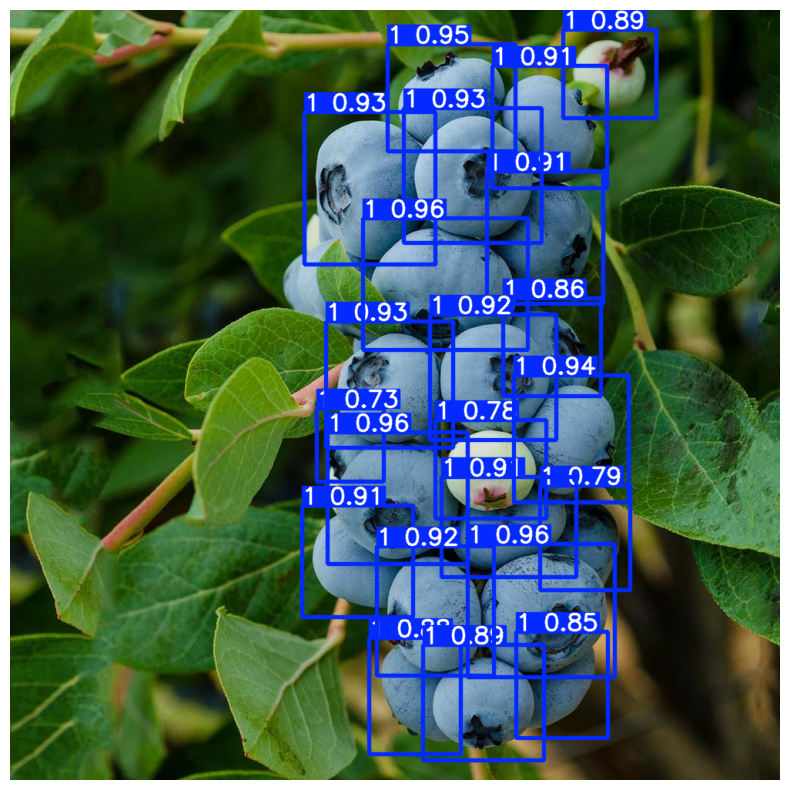

Saved output folder: /content/runs/detect/predict3


In [23]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()  # upload your test image (jpg/png)
img_path = next(iter(uploaded.keys()))
print("Uploaded:", img_path)

results = model.predict(
    source=img_path,
    imgsz=640,     # try 1024 if berries are very small
    conf=0.25,
    save=True
)

# count detections
det_count = 0 if results[0].boxes is None else len(results[0].boxes)
print("✅ Detected berries:", det_count)

# show image with boxes
annotated = results[0].plot()  # numpy array (BGR)
plt.figure(figsize=(10,10))
plt.imshow(annotated[..., ::-1])  # convert BGR -> RGB
plt.axis("off")
plt.show()

print("Saved output folder:", results[0].save_dir)

In [24]:
import os, glob, shutil
from pathlib import Path

PUB = Path("/content/github_publish")
PUB.mkdir(exist_ok=True)

# folders
(PUB/"notebooks").mkdir(exist_ok=True)
(PUB/"weights").mkdir(exist_ok=True)
(PUB/"results").mkdir(exist_ok=True)
(PUB/"assets/predictions").mkdir(parents=True, exist_ok=True)

# 1) fixed yaml
if Path("/content/fixed_data.yaml").exists():
    shutil.copy("/content/fixed_data.yaml", PUB/"fixed_data.yaml")

# 2) weights
best = Path("runs/detect/train/weights/best.pt")
if best.exists():
    shutil.copy(best, PUB/"weights/best.pt")

# 3) training outputs (optional but nice)
train_dir = Path("runs/detect/train")
for f in ["results.csv", "results.png", "confusion_matrix.png", "PR_curve.png", "P_curve.png", "R_curve.png", "F1_curve.png"]:
    fp = train_dir/f
    if fp.exists():
        shutil.copy(fp, PUB/"results"/fp.name)

# 4) your CSV outputs (if you created them)
for f in ["/content/berry_count_eval.csv", "/content/berry_pred_counts.csv", "/content/berry_count_eval_val.csv"]:
    fp = Path(f)
    if fp.exists():
        shutil.copy(fp, PUB/"results"/fp.name)

# 5) copy 8 sample prediction images from latest predict folder
pred_dirs = sorted(Path("runs/detect").glob("predict*"), key=lambda p: p.stat().st_mtime)
if pred_dirs:
    latest_pred = pred_dirs[-1]
    imgs = []
    for ext in ["*.jpg","*.jpeg","*.png","*.webp"]:
        imgs += list(latest_pred.glob(ext))
    imgs = sorted(imgs)[:8]
    for i, img in enumerate(imgs, 1):
        shutil.copy(img, PUB/f"assets/predictions/sample_{i:02d}{img.suffix}")

print("✅ Ready-to-upload folder:", PUB)
!find /content/github_publish -maxdepth 3 -type f | sed -n '1,120p'

✅ Ready-to-upload folder: /content/github_publish
/content/github_publish/results/berry_count_eval.csv
/content/github_publish/results/results.png
/content/github_publish/results/results.csv
/content/github_publish/results/berry_pred_counts.csv
/content/github_publish/results/confusion_matrix.png
/content/github_publish/fixed_data.yaml
/content/github_publish/assets/predictions/sample_04.jpg
/content/github_publish/assets/predictions/sample_01.jpg
/content/github_publish/assets/predictions/sample_03.jpg
/content/github_publish/assets/predictions/sample_02.jpg
/content/github_publish/weights/best.pt


In [25]:
from ultralytics import YOLO
import json

# Load best weights
model = YOLO("runs/detect/train/weights/best.pt")

# Run validation (use same imgsz you trained with; you used 640)
val_res = model.val(data="/content/fixed_data.yaml", imgsz=640, conf=0.25)

# Ultralytics usually stores bbox metrics under val_res.box
# We'll extract safely (works across versions)
def safe_get(obj, attr_chain, default=None):
    cur = obj
    for a in attr_chain.split("."):
        if not hasattr(cur, a):
            return default
        cur = getattr(cur, a)
    return cur

mp    = safe_get(val_res, "box.mp")       # precision mean
mr    = safe_get(val_res, "box.mr")       # recall mean
map50 = safe_get(val_res, "box.map50")    # mAP@0.5
map95 = safe_get(val_res, "box.map")      # mAP@0.5:0.95

print("Precision (mp):", mp)
print("Recall (mr):", mr)
print("mAP@0.5:", map50)
print("mAP@0.5:0.95:", map95)

# Save to a file for README copy/paste
metrics_out = {
    "precision_mp": mp,
    "recall_mr": mr,
    "map50": map50,
    "map50_95": map95
}
with open("/content/metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print("✅ Saved: /content/metrics.json")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1601.7±440.8 MB/s, size: 110.4 KB)
val: Scanning /content/dataset/valid/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 1.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all          8        571      0.905      0.853      0.918      0.597
Speed: 5.4ms preprocess, 10.8ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/runs/detect/val3
Precision (mp): 0.9048073865559888
Recall (mr): 0.8528896672504378
mAP@0.5: 0.9175473780412611
mAP@0.5:0.95: 0.5972979779064567
✅ Saved: /content/metrics.json


In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/berry_count_eval.csv")  # or berry_count_eval_val.csv
# Works if your CSV has columns: error, abs_error (from earlier code)
if "error" not in df.columns:
    df["error"] = df["pred_count"] - df["gt_count"]
if "abs_error" not in df.columns:
    df["abs_error"] = (df["error"]).abs()

mae = df["abs_error"].mean()
rmse = np.sqrt((df["error"]**2).mean())

print("MAE:", mae)
print("RMSE:", rmse)

df.head()

MAE: 9.0
RMSE: 10.747092630102339


,image,gt_count,pred_count,error,abs_error
0,65897A--1-_jpg.rf.8db1687650801c5fd3fe843f7501...,35,47,12,12
1,BU133-2_jpg.rf.b55d46e3b91a4e163ea97056a7debc6...,8,14,6,6
2,Dreamstime_blueberry_bush_large_jpg.rf.a209992...,29,34,5,5
3,Sunshineblue09sq_jpeg.rf.735bf1ee5924498dedd8b...,39,35,-4,4
4,blueberry-vaccinium-nelson-9cm-p3876-30388_ima...,194,177,-17,17
